<a href="https://colab.research.google.com/github/tasmimjoti/Machine-Learning-in-Business/blob/main/Predictive_Analytics_for_Green_Bond_Performance_Using_Machine_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns
import lightgbm as lgb
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import StackingRegressor
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.inspection import permutation_importance

In [ ]:
df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Predictive Analytics for Green Bond Performance Using Machine Learning/synthetic_green_bond_data_with_real_issuers.csv")

In [ ]:
df = df.drop(columns=['Issuer_Name'])

In [ ]:
df = df.sort_index()

In [ ]:
# One-hot encode categorical variables
categorical_cols = ['Issuer_Location', 'Issuer_Sector', 'Credit_Rating', 'Risk_Involved']
df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

In [ ]:
# Define features and target
X = df.drop(columns=['Bond_Price'])
y = df['Bond_Price']

In [ ]:
# Simulate time-based train-test split (80% train, 20% test)
split_index = int(len(df) * 0.8)
X_train, X_test = X.iloc[:split_index], X.iloc[split_index:]
y_train, y_test = y.iloc[:split_index], y.iloc[split_index:]

In [ ]:
# Train model
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [ ]:
# Predict
y_pred = model.predict(X_test)

In [ ]:
# Evaluation metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"MAE: {mae:.4f}")
print(f"MSE: {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R²: {r2:.4f}")

MAE: 0.7783
MSE: 0.9587
RMSE: 0.9791
R²: 0.9301


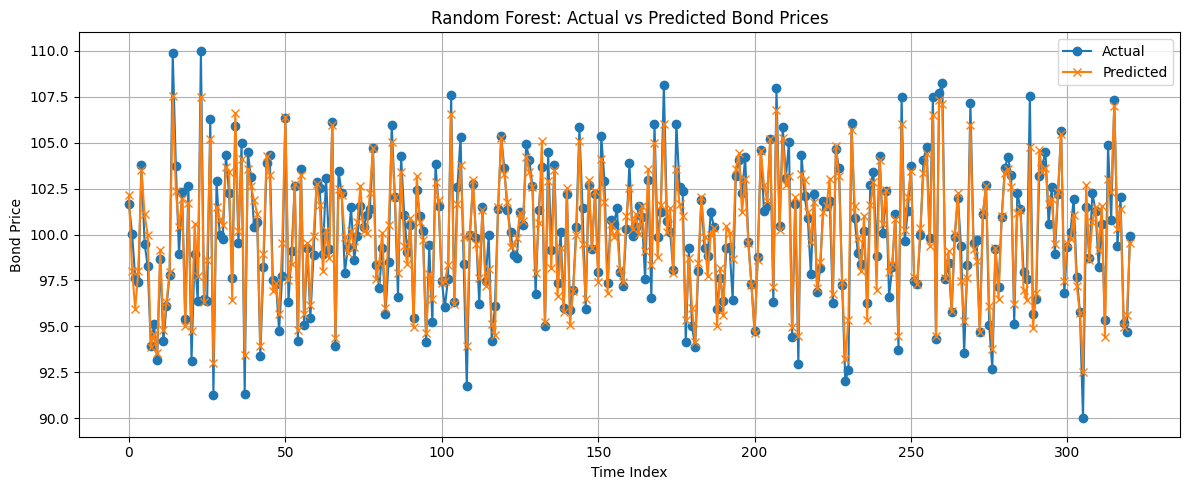

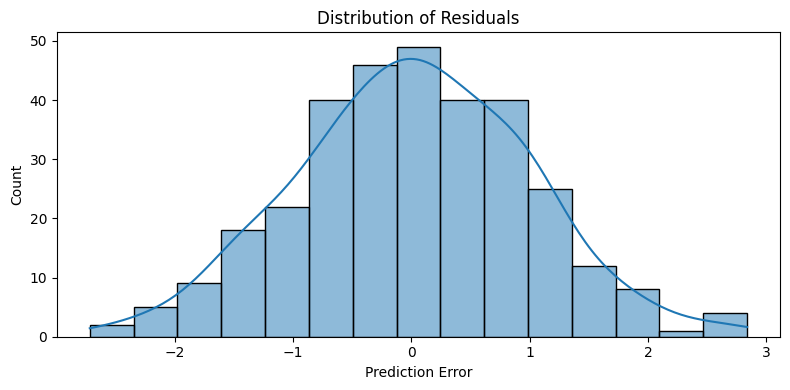

In [ ]:
# Actual vs Predicted
plt.figure(figsize=(12, 5))
plt.plot(y_test.values, label='Actual', marker='o')
plt.plot(y_pred, label='Predicted', marker='x')
plt.title('Random Forest: Actual vs Predicted Bond Prices')
plt.xlabel('Time Index')
plt.ylabel('Bond Price')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Residual plot
residuals = y_test - y_pred
plt.figure(figsize=(8, 4))
sns.histplot(residuals, kde=True)
plt.title('Distribution of Residuals')
plt.xlabel('Prediction Error')
plt.tight_layout()
plt.show()

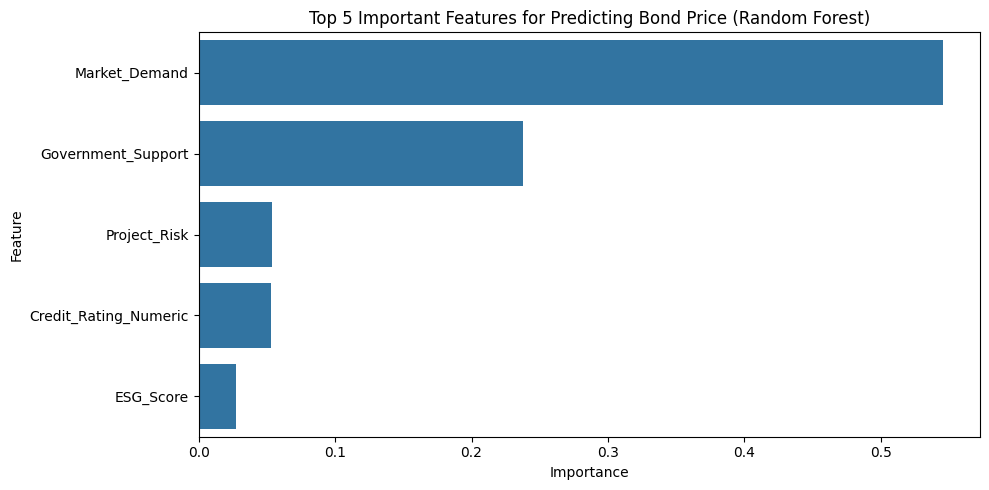

In [ ]:
# Feature importance
importances = model.feature_importances_
feature_names = X_train.columns
importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
importance_df = importance_df.sort_values('Importance', ascending=False)

# Plot feature importances
plt.figure(figsize=(10, 5))
sns.barplot(x='Importance', y='Feature', data=importance_df.head(5))
plt.title('Top 5 Important Features for Predicting Bond Price (Random Forest)')
plt.tight_layout()
plt.show()

In [ ]:
# XGBoost model
model_xgb = xgb.XGBRegressor(objective='reg:squarederror', n_estimators=100, random_state=42)
model_xgb.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=None, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=None, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=100, n_jobs=None,
             num_parallel_tree=None, random_state=42, ...)

In [ ]:
# Predictions
y_pred_xgb = model_xgb.predict(X_test)

In [ ]:
# Evaluation
mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
mse_xgb = mean_squared_error(y_test, y_pred_xgb)
rmse_xgb = np.sqrt(mse_xgb)
r2_xgb = r2_score(y_test, y_pred_xgb)

print(f"XGBoost MAE: {mae_xgb:.4f}")
print(f"XGBoost MSE: {mse_xgb:.4f}")
print(f"XGBoost RMSE: {np.sqrt(mse_xgb):.4f}")
print(f"XGBoost R²: {r2_xgb:.4f}")

XGBoost MAE: 0.6358
XGBoost MSE: 0.6540
XGBoost RMSE: 0.8087
XGBoost R²: 0.9523


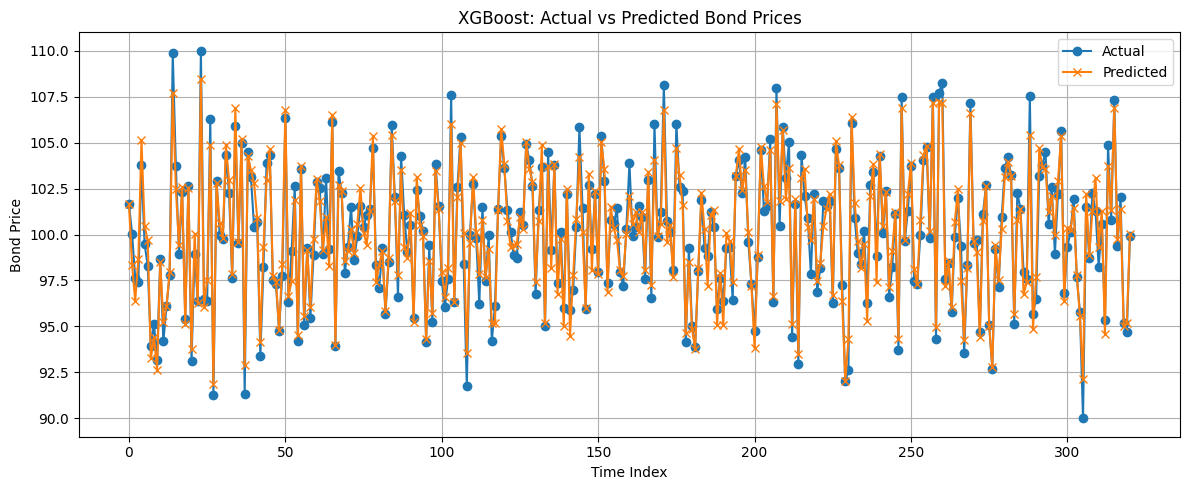

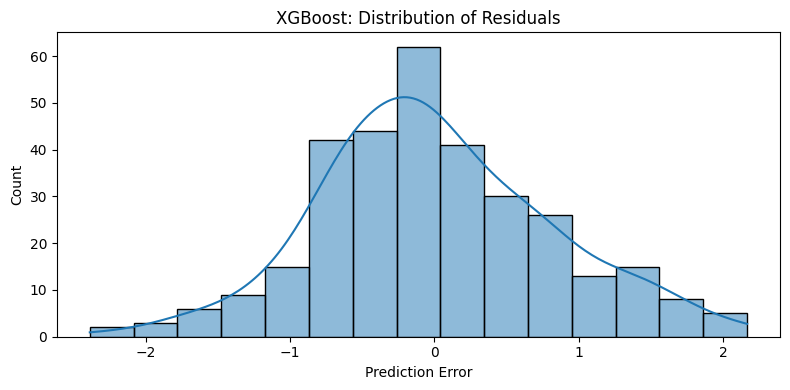

In [ ]:
# Actual vs Predicted
plt.figure(figsize=(12, 5))
plt.plot(y_test.values, label='Actual', marker='o')
plt.plot(y_pred_xgb, label='Predicted', marker='x')
plt.title('XGBoost: Actual vs Predicted Bond Prices')
plt.xlabel('Time Index')
plt.ylabel('Bond Price')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Residual Plot
residuals_xgb = y_test.values - y_pred_xgb
plt.figure(figsize=(8, 4))
sns.histplot(residuals_xgb, kde=True)
plt.title('XGBoost: Distribution of Residuals')
plt.xlabel('Prediction Error')
plt.tight_layout()
plt.show()

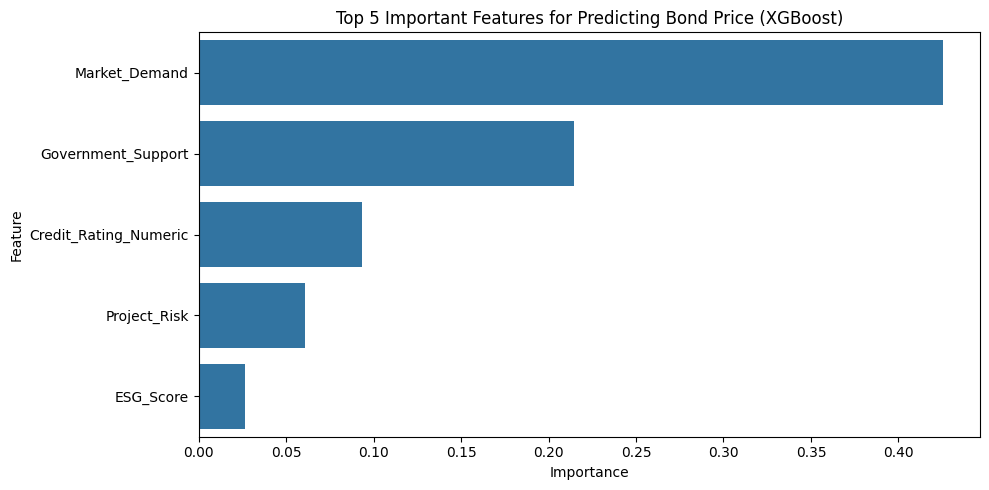

In [ ]:
# Feature importance
importances = model_xgb.feature_importances_
feature_names = X_train.columns
importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
importance_df = importance_df.sort_values('Importance', ascending=False)

# Plot feature importances
plt.figure(figsize=(10, 5))
sns.barplot(x='Importance', y='Feature', data=importance_df.head(5))
plt.title('Top 5 Important Features for Predicting Bond Price (XGBoost)')
plt.tight_layout()
plt.show()

In [ ]:
estimators = [
    ('rf', RandomForestRegressor(n_estimators=100, random_state=42)),
    ('lgbm', lgb.LGBMRegressor(n_estimators=100, random_state=42))
]

In [ ]:
# Stacking regressor with Ridge meta-model
stacking_regressor = StackingRegressor(
    estimators=estimators,
    final_estimator=Ridge(alpha=1.0),
    cv=5,
    n_jobs=-1
)

In [ ]:
# Fit on training data
stacking_regressor.fit(X_train, y_train)

StackingRegressor(cv=5,
                  estimators=[('rf', RandomForestRegressor(random_state=42)),
                              ('lgbm', LGBMRegressor(random_state=42))],
                  final_estimator=Ridge(), n_jobs=-1)

In [ ]:
# Predict on test data
stack_pred = stacking_regressor.predict(X_test)

In [ ]:
# Evaluate predictions
mae = mean_absolute_error(y_test, stack_pred)
mse = mean_squared_error(y_test, stack_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, stack_pred)

print(f"MAE: {mae:.4f}")
print(f"MSE: {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R2: {r2:.4f}")

MAE: 0.4408
MSE: 0.3215
RMSE: 0.5670
R2: 0.9766


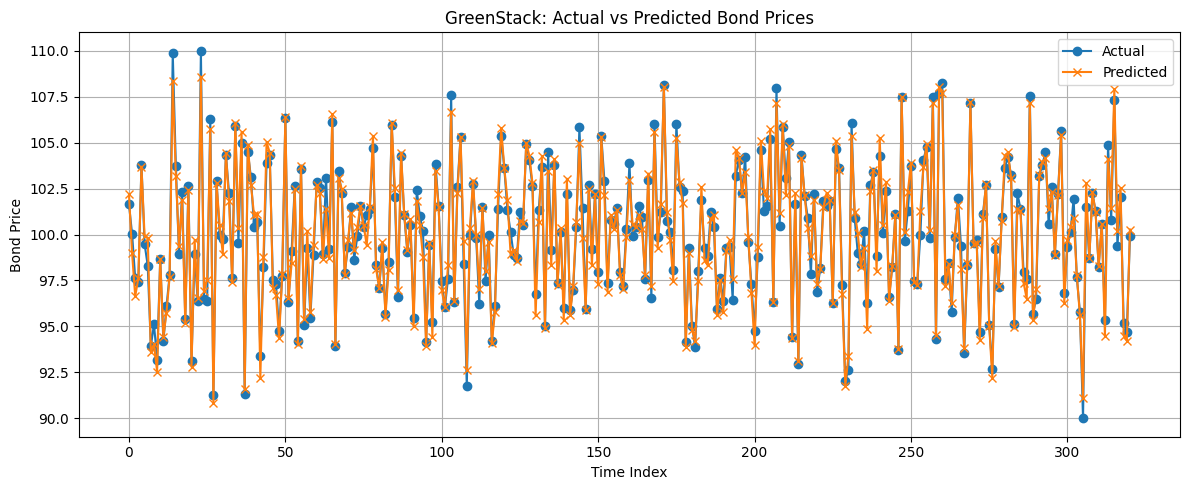

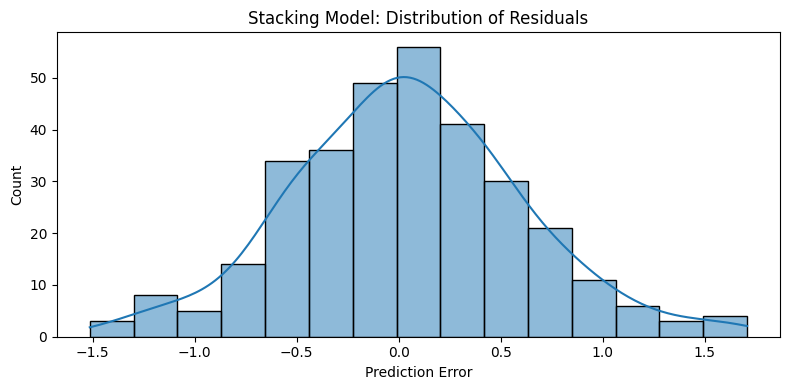

In [ ]:
# Plot Actual vs Predicted
plt.figure(figsize=(12, 5))
plt.plot(y_test.values, label='Actual', marker='o')
plt.plot(stack_pred, label='Predicted', marker='x')
plt.title('GreenStack: Actual vs Predicted Bond Prices')
plt.xlabel('Time Index')
plt.ylabel('Bond Price')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Residual Plot
residuals_stack = y_test.values - stack_pred
plt.figure(figsize=(8, 4))
sns.histplot(residuals_stack, kde=True)
plt.title('Stacking Model: Distribution of Residuals')
plt.xlabel('Prediction Error')
plt.tight_layout()
plt.show()

<ipython-input-24-792f9b0fcac7>:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=top_features, palette='rocket')


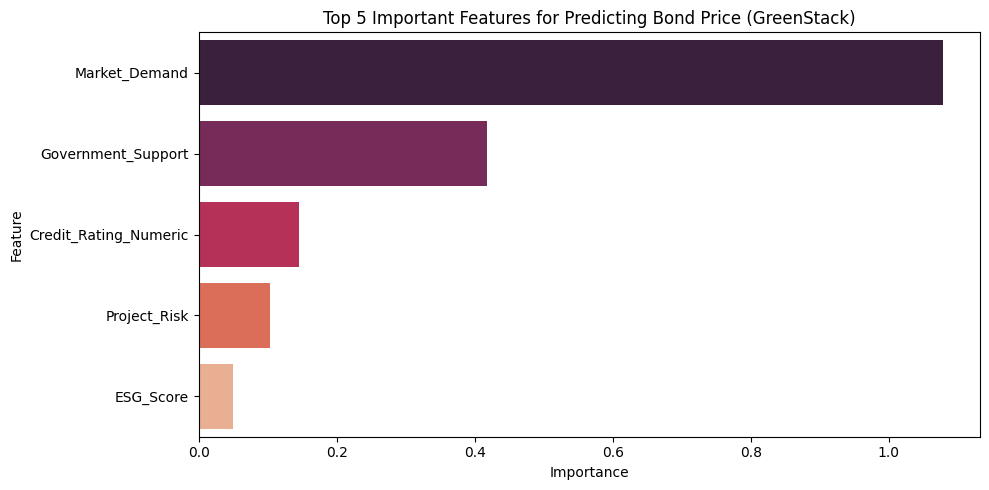

In [ ]:
# Step 1: Compute Permutation Importance
result = permutation_importance(
    stacking_regressor, X_test, y_test,
    n_repeats=10, random_state=42, n_jobs=-1
)

# Step 2: Convert to DataFrame
perm_df = pd.DataFrame({
    'Feature': X_test.columns,
    'Importance': result.importances_mean
}).sort_values(by='Importance', ascending=False)

# Step 3: Select Top N Features
top_n = 5
top_features = perm_df.head(top_n)

# Step 4: Plot
plt.figure(figsize=(10, 5))
sns.barplot(x='Importance', y='Feature', data=top_features, palette='rocket')
plt.title(f'Top {top_n} Important Features for Predicting Bond Price (GreenStack)')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()